## Import librerie e dataset

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("TMDB_movie_dataset_v11.csv")
df.shape

(1387276, 24)

In [3]:
pd.set_option('display.max_columns', None)

df.head()

,id,title,vote_average,vote_count,status,release_date,revenue,runtime,adult,backdrop_path,budget,homepage,imdb_id,original_language,original_title,overview,popularity,poster_path,tagline,genres,production_companies,production_countries,spoken_languages,keywords
0,27205,Inception,8.364,34495,Released,2010-07-15,825532764,148,False,/8ZTVqvKDQ8emSGUEMjsS4yHAwrp.jpg,160000000,https://www.warnerbros.com/movies/inception,tt1375666,en,Inception,"Cobb, a skilled thief who commits corporate es...",83.952,/oYuLEt3zVCKq57qu2F8dT7NIa6f.jpg,Your mind is the scene of the crime.,"Action, Science Fiction, Adventure","Legendary Pictures, Syncopy, Warner Bros. Pict...","United Kingdom, United States of America","English, French, Japanese, Swahili","rescue, mission, dream, airplane, paris, franc..."
1,157336,Interstellar,8.417,32571,Released,2014-11-05,701729206,169,False,/pbrkL804c8yAv3zBZR4QPEafpAR.jpg,165000000,http://www.interstellarmovie.net/,tt0816692,en,Interstellar,The adventures of a group of explorers who mak...,140.241,/gEU2QniE6E77NI6lCU6MxlNBvIx.jpg,Mankind was born on Earth. It was never meant ...,"Adventure, Drama, Science Fiction","Legendary Pictures, Syncopy, Lynda Obst Produc...","United Kingdom, United States of America",English,"rescue, future, spacecraft, race against time,..."
2,155,The Dark Knight,8.512,30619,Released,2008-07-16,1004558444,152,False,/nMKdUUepR0i5zn0y1T4CsSB5chy.jpg,185000000,https://www.warnerbros.com/movies/dark-knight/,tt0468569,en,The Dark Knight,Batman raises the stakes in his war on crime. ...,130.643,/qJ2tW6WMUDux911r6m7haRef0WH.jpg,Welcome to a world without rules.,"Drama, Action, Crime, Thriller","DC Comics, Legendary Pictures, Syncopy, Isobel...","United Kingdom, United States of America","English, Mandarin","joker, sadism, chaos, secret identity, crime f..."
3,19995,Avatar,7.573,29815,Released,2009-12-15,2923706026,162,False,/vL5LR6WdxWPjLPFRLe133jXWsh5.jpg,237000000,https://www.avatar.com/movies/avatar,tt0499549,en,Avatar,"In the 22nd century, a paraplegic Marine is di...",79.932,/kyeqWdyUXW608qlYkRqosgbbJyK.jpg,Enter the world of Pandora.,"Action, Adventure, Fantasy, Science Fiction","Dune Entertainment, Lightstorm Entertainment, ...","United States of America, United Kingdom","English, Spanish","future, society, culture clash, space travel, ..."
4,24428,The Avengers,7.710,29166,Released,2012-04-25,1518815515,143,False,/9BBTo63ANSmhC4e6r62OJFuK2GL.jpg,220000000,https://www.marvel.com/movies/the-avengers,tt0848228,en,The Avengers,When an unexpected enemy emerges and threatens...,98.082,/RYMX2wcKCBAr24UyPD7xwmjaTn.jpg,Some assembly required.,"Science Fiction, Action, Adventure",Marvel Studios,United States of America,"English, Hindi, Russian","new york city, superhero, shield, based on com..."


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1387276 entries, 0 to 1387275
Data columns (total 24 columns):
 #   Column                Non-Null Count    Dtype  
---  ------                --------------    -----  
 0   id                    1387276 non-null  int64  
 1   title                 1387258 non-null  str    
 2   vote_average          1387276 non-null  float64
 3   vote_count            1387276 non-null  int64  
 4   status                1387276 non-null  str    
 5   release_date          1088000 non-null  str    
 6   revenue               1387276 non-null  int64  
 7   runtime               1387276 non-null  int64  
 8   adult                 1387276 non-null  bool   
 9   backdrop_path         347154 non-null   str    
 10  budget                1387276 non-null  int64  
 11  homepage              143090 non-null   str    
 12  imdb_id               661222 non-null   str    
 13  original_language     1387276 non-null  str    
 14  original_title        1387258 non-null  str  

In [5]:
df["status"].value_counts()

status
Released           1339413
In Production        21298
Post Production      14543
Planned              10947
Rumored                714
Canceled               361
Name: count, dtype: int64

## Filtraggio dataset
Manteniamo solo i film con status "Released" perché vogliamo addestrare 
il modello su dati reali e completi. Film in produzione o non ancora 
usciti hanno revenue = 0, il che falsificherebbe le predizioni.

In [6]:
df = df[df["status"] == "Released"]
df.shape

(1339413, 24)

### Selezione delle feature
Teniamo solo le colonne utili per il modello, escludendo:
- Identificatori e URL (id, title, imdb_id, poster_path, ecc.) — non hanno potere predittivo
- Testo libero (overview, tagline, keywords) — richiederebbe NLP
- vote_average e popularity — non disponibili prima dell'uscita del film, usarle sarebbe data leakage
- vote_count — è una conseguenza del successo del film, non una causa

In [7]:
cols = ["revenue", "budget", "runtime", "genres", "original_language", "release_date"]
df = df[cols]
df.shape

(1339413, 6)

In [8]:
df.isnull().sum()

revenue                   0
budget                    0
runtime                   0
genres               590774
original_language         0
release_date         271419
dtype: int64

In [9]:
(df["revenue"] == 0).sum()

np.int64(1315886)

In [10]:
df = df[df["revenue"] > 0]
df.shape

(23526, 6)

In [11]:
(df["budget"] == 0).sum()

np.int64(6844)

In [12]:
df = df[df["budget"] > 0]
df.shape

(16682, 6)

In [13]:
df.isnull().sum()

revenue                 0
budget                  0
runtime                 0
genres               2918
original_language       0
release_date         3056
dtype: int64

In [14]:
df = df.dropna(subset=["genres", "release_date"])
df.shape

(13147, 6)

Rimossi i film con revenue o budget pari a 0 (dati non disponibili).
Rimossi i film con valori mancanti in genres e release_date perchè sono feature importanti per il modello, 
imputarle con valori fittizi introdurrebbe rumore nel modello

# <br>
# <br>

## Analisi Esplorativa e Pulizia dei Dati

In [15]:
df.describe()

,revenue,budget,runtime
count,1.314700e+04,1.314700e+04,13147.000000
mean,5.471020e+07,1.893738e+07,89.838290
std,1.594525e+08,3.795723e+07,54.908697
min,1.000000e+00,1.000000e+00,0.000000
25%,4.195150e+04,4.583900e+04,81.000000
50%,4.922166e+06,4.520000e+06,99.000000
75%,3.860500e+07,2.000000e+07,116.000000
max,5.000000e+09,8.000000e+08,999.000000


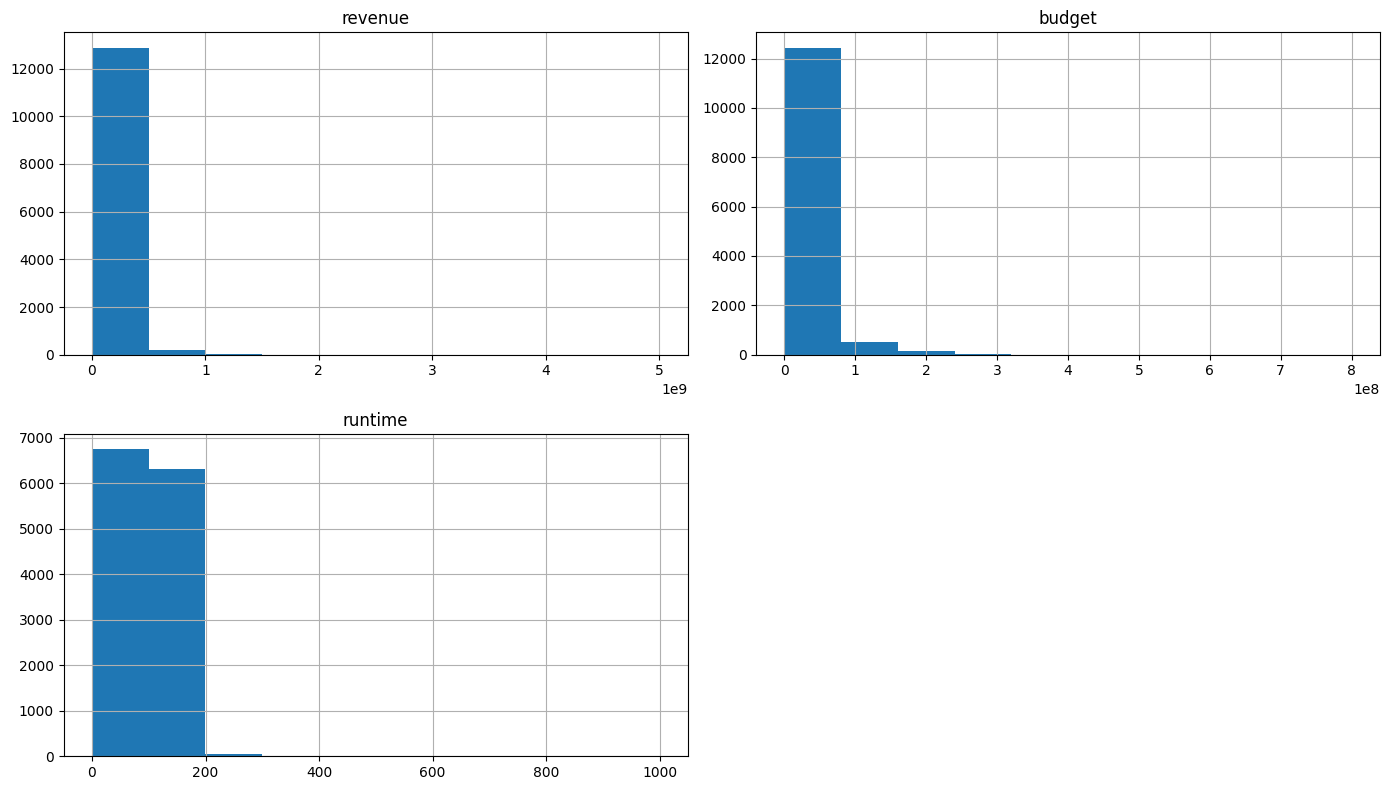

In [16]:
df.hist(figsize=(14, 8))
plt.tight_layout()
plt.show()

In [17]:
df[df["runtime"] == 0].shape[0]

1041

In [18]:
df[(df["runtime"] > 0) & (df["runtime"] < 60)].shape[0]

1685

In [19]:
df[df["runtime"] > 240].shape[0]

52

In [20]:
df[df["runtime"] > 240][["runtime", "revenue", "budget"]].sort_values("runtime", ascending=False).head(10)

,runtime,revenue,budget
348037,999,319700000,150000000
308424,999,469000000,200000000
308487,999,135395253,80000000
783394,999,479,111
297000,990,19,19
318843,987,495400000,10500000
184341,980,6,12
319199,975,40000000,7500000
646674,915,90,100
487076,800,40000,20000


### Filtraggio runtime
Rimuoviamo i film con runtime minore di 60 minuti (cortometraggi) e maggiore di 240 minuti (valori anomali). I cortometraggi hanno dinamiche di budget e revenue completamente diverse dai lungometraggi e distorcerebbero il modello.

In [21]:
df = df[(df["runtime"] > 60) & (df["runtime"] <= 240)]
df.shape

(10341, 6)

In [22]:
df[df["budget"] < 10000]["budget"].sort_values().head(20)

1373202    1
301049     1
59825      1
58410      1
816584     1
816583     1
308040     1
63238      1
95604      1
315798     1
729747     1
116574     1
290741     1
595183     1
153755     1
182652     1
1089448    1
1070971    1
1166577    1
868836     1
Name: budget, dtype: int64

In [23]:
df[df["budget"] < 10000]["budget"].value_counts().sort_index()

budget
1       26
2       13
3        7
4        9
5       12
        ..
9684     1
9728     1
9811     1
9888     1
9990     1
Name: count, Length: 205, dtype: int64

In [24]:
df[df["revenue"] < 10000]["revenue"].value_counts().sort_index()

revenue
1       21
2       19
3       11
4        9
5        7
        ..
9866     1
9885     1
9886     1
9887     1
9984     1
Name: count, Length: 249, dtype: int64

In [25]:
df[["revenue", "budget"]].quantile([0.01, 0.02, 0.03, 0.04, 0.05, 0.06, 0.07, 0.08, 0.08, 0.09, 0.10])

,revenue,budget
0.01,15.0,16.8
0.02,100.0,124.0
0.03,1000.0,1000.0
0.04,5000.0,5583.8
0.05,10000.0,10000.0
0.06,12323.4,10000.0
0.07,21748.2,25000.0
0.08,35084.6,55000.0
0.08,35084.6,55000.0
0.09,53976.0,100000.0


In [26]:
df[["revenue", "budget"]].quantile([0.10, 0.15, 0.20, 0.25, 0.30])

,revenue,budget
0.10,88097.0,130000.0
0.15,326563.0,500000.0
0.20,898365.0,1000000.0
0.25,1595417.0,1900000.0
0.30,2500000.0,2870000.0


In [27]:
rev_10 = df["revenue"].quantile(0.10)
rev_20 = df["revenue"].quantile(0.20)

df[(df["revenue"] >= rev_10) & (df["revenue"] <= rev_20)][["revenue", "budget", "genres"]].sort_values("revenue").head(20)

,revenue,budget,genres
41405,88097,400000,Documentary
5522,88273,2400000,"Romance, Comedy, Horror"
332429,89038,15000000,"Drama, Action, Horror"
23115,89182,5500000,"Comedy, Thriller, Action, Drama"
4789,89237,10000000,"Drama, Fantasy, Thriller"
14776,89487,980000,"Drama, Fantasy"
16736,89781,6500000,"Comedy, Drama"
62539,89932,1460910,"Drama, Thriller"
1073503,90000,10000,"Documentary, TV Movie"
262115,90000,10000,"Drama, Mystery, Thriller"


In [28]:
rev_20 = df["revenue"].quantile(0.20)
bud_20 = df["budget"].quantile(0.20)

df = df[(df["revenue"] >= rev_20) & (df["budget"] >= bud_20)]
df.shape

(7583, 6)

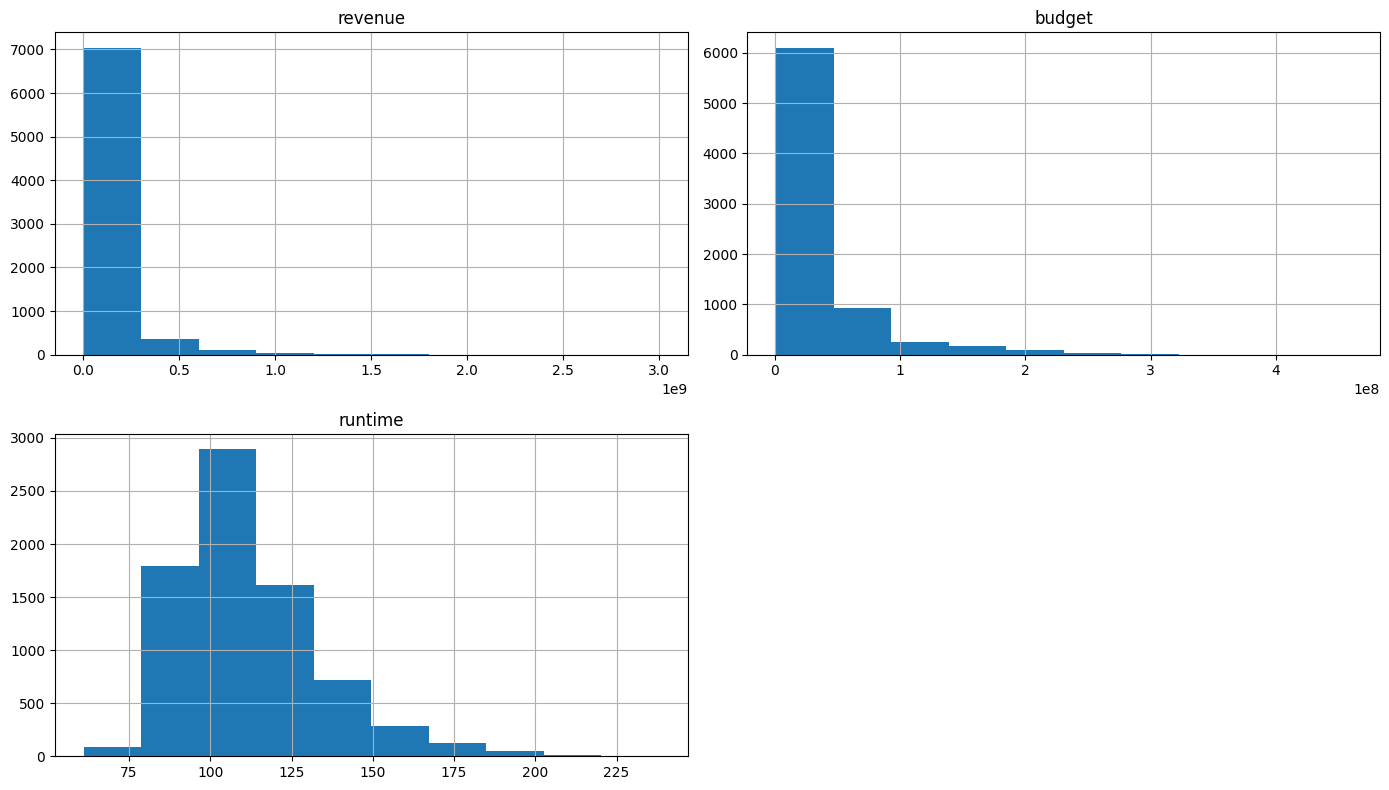

In [29]:
df.hist(figsize=(14, 8))
plt.tight_layout()
plt.show()

## Rimozione outlier e valori anomali
Rimossi i film con runtime = 0 e > 240 minuti e i valori sotto il 20° percentile di revenue e budget, in quanto chiaramente dati errati o placeholder.

# <br>
# <br>

### Matrice di correlazione
Visualizziamo le correlazioni tra le variabili numeriche per capire quali feature sono più legate al revenue.

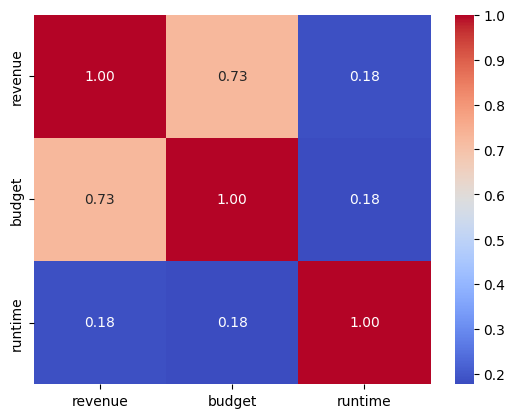

In [30]:
sns.heatmap(df.corr(numeric_only=True), annot=True, fmt=".2f", cmap="coolwarm")
plt.show()

# <br>

### Distribuzione del Revenue
Visualizziamo la distribuzione del revenue nella scala originale. La distribuzione è fortemente asimmetrica (right-skewed) — la maggior parte dei film incassa poco mentre pochi film incassano miliardi. La trasformazione logaritmica è fondamentale per la regressione lineare e può aiutare anche i modelli ad albero riducendo l'influenza degli outlier.

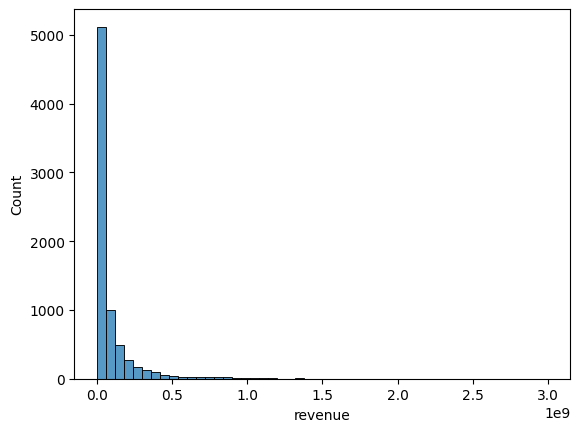

In [31]:
sns.histplot(df["revenue"], bins=50)
plt.show()

# <br>

### Distribuzione del Revenue con trasformazione logaritmica
Applichiamo np.log1p() al revenue per ottenere una distribuzione più simmetrica. È una trasformazione reversibile — alla fine con np.expm1() si ritorna ai valori originali in dollari.

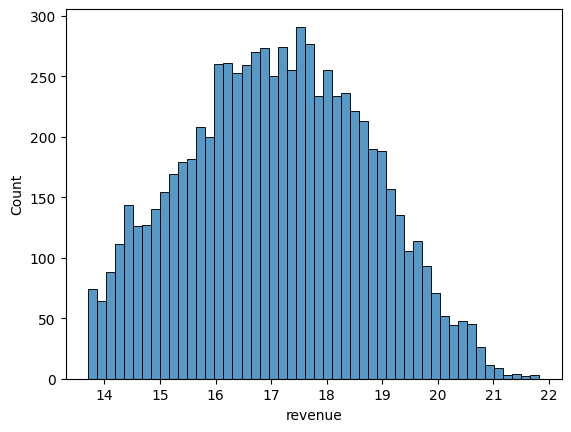

In [32]:
sns.histplot(np.log1p(df["revenue"]), bins=50)
plt.show()

### Applicazione della trasformazione logaritmica al revenue e al budget
Sostituiamo il revenue originale con il suo logaritmo. Questa sarà la variabile target del modello.
Sostituisco anche il budget con il suo logaritmo perchè anche budget è molto sbilanciato

In [33]:
df["revenue"] = np.log1p(df["revenue"])
df["budget"] = np.log1p(df["budget"])

### Relazione tra budget e revenue
Visualizziamo la relazione tra budget e revenue, entrambi in scala logaritmica. La relazione quasi lineare conferma che il budget è una feature molto importante per il modello

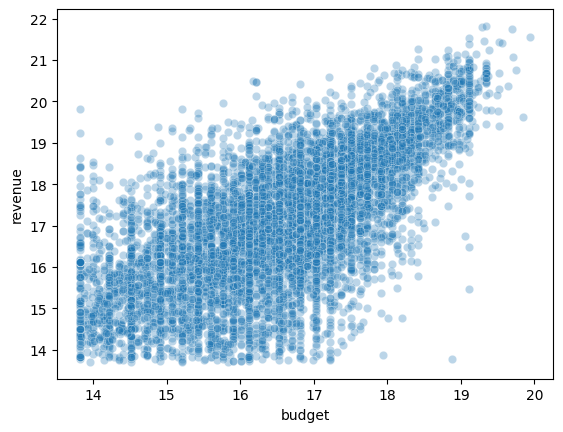

In [34]:
sns.scatterplot(data=df, x="budget", y="revenue", alpha=0.3)
plt.show()

# <br>
# <br>

## Feature Engineering
In questa sezione trasformiamo le colonne non numeriche in feature numeriche utilizzabili dal modello.
# <br>

### Estrazione features da release_date
Estraiamo mese e anno dalla data di uscita come feature numeriche. Il mese cattura la stagionalità (estate e natale tendono ad avere revenue più alti), l'anno cattura il trend storico del mercato cinematografico.

In [35]:
df["release_date"] = pd.to_datetime(df["release_date"])
df["release_month"] = df["release_date"].dt.month
df["release_year"] = df["release_date"].dt.year
df = df.drop(columns=["release_date"])
df.head()

,revenue,budget,runtime,genres,original_language,release_month,release_year
0,20.531540,18.890684,148,"Action, Science Fiction, Adventure",en,7,2010
1,20.369058,18.921456,169,"Adventure, Drama, Science Fiction",en,11,2014
2,20.727814,19.035866,152,"Drama, Action, Crime, Thriller",en,7,2008
3,21.796118,19.283571,162,"Action, Adventure, Fantasy, Science Fiction",en,12,2009
4,21.141197,19.209138,143,"Science Fiction, Action, Adventure",en,4,2012


In [36]:
df.release_month.describe()

count    7583.000000
mean        6.972834
std         3.403576
min         1.000000
25%         4.000000
50%         7.000000
75%        10.000000
max        12.000000
Name: release_month, dtype: float64

In [37]:
df.release_year.describe()


count    7583.000000
mean     2001.780034
std        16.520944
min      1914.000000
25%      1995.000000
50%      2006.000000
75%      2014.000000
max      2025.000000
Name: release_year, dtype: float64

### Encoding ciclico del mese di uscita
Il mese è una variabile ciclica — dicembre e gennaio sono vicini nel calendario ma lontani numericamente. Usiamo l'encoding sinusoidale per catturare questa ciclicità, creando due feature: month_sin e month_cos.

In [38]:
df["month_sin"] = np.sin(2 * np.pi * df["release_month"] / 12)
df["month_cos"] = np.cos(2 * np.pi * df["release_month"] / 12)
df = df.drop(columns=["release_month"])

In [39]:
df[["release_year", "month_sin", "month_cos"]].dtypes

release_year      int32
month_sin       float64
month_cos       float64
dtype: object

In [40]:
df["original_language"].value_counts()

original_language
en    6198
hi     261
fr     230
ru     138
es     110
ja      80
zh      74
ko      66
it      60
te      49
ta      45
de      43
ml      27
cn      26
no      21
pt      17
sv      14
tr      13
da      11
nl      11
fi       9
th       8
ar       8
pl       6
he       6
vi       5
kn       5
ms       4
ur       4
pa       4
tl       4
fa       3
bn       3
id       2
hu       2
uk       2
ro       2
cs       2
mr       2
nb       1
la       1
gl       1
tn       1
ca       1
iu       1
hr       1
sk       1
Name: count, dtype: int64

### Encoding original_language
La lingua inglese rappresenta l'82% del dataset. Convertiamo la colonna in una feature binaria: 1 se il film è in inglese, 0 altrimenti.

In [41]:
df["is_english"] = (df["original_language"] == "en").astype(int)
df = df.drop(columns=["original_language"])
df["is_english"].value_counts()

is_english
1    6198
0    1385
Name: count, dtype: int64

In [42]:
df["genres"].head(10)

0             Action, Science Fiction, Adventure
1              Adventure, Drama, Science Fiction
2                 Drama, Action, Crime, Thriller
3    Action, Adventure, Fantasy, Science Fiction
4             Science Fiction, Action, Adventure
5                      Action, Adventure, Comedy
6             Adventure, Action, Science Fiction
7                                          Drama
8             Action, Science Fiction, Adventure
9                                Thriller, Crime
Name: genres, dtype: str

### Encoding dei generi
I generi sono una stringa con valori multipli separati da virgola. Usiamo MultiLabelBinarizer di sklearn per creare una colonna binaria per ognuno dei 19 generi. Mettiamo 1 se il film appartiene a quel genere, 0 altrimenti. Salveremo il binarizer addestrato per riusarlo nella webapp.

In [43]:
from sklearn.preprocessing import MultiLabelBinarizer

mlb = MultiLabelBinarizer()
genres_list = df["genres"].str.split(", ")
genres_encoded = mlb.fit_transform(genres_list)
genres_df = pd.DataFrame(genres_encoded, columns=mlb.classes_, index=df.index)
df = pd.concat([df, genres_df], axis=1)
df = df.drop(columns=["genres"])
df.head()

,revenue,budget,runtime,release_year,month_sin,month_cos,is_english,Action,Adventure,Animation,Comedy,Crime,Documentary,Drama,Family,Fantasy,History,Horror,Music,Mystery,Romance,Science Fiction,TV Movie,Thriller,War,Western
0,20.531540,18.890684,148,2010,-5.000000e-01,-0.866025,1,1,1,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0
1,20.369058,18.921456,169,2014,-5.000000e-01,0.866025,1,0,1,0,0,0,0,1,0,0,0,0,0,0,0,1,0,0,0,0
2,20.727814,19.035866,152,2008,-5.000000e-01,-0.866025,1,1,0,0,0,1,0,1,0,0,0,0,0,0,0,0,0,1,0,0
3,21.796118,19.283571,162,2009,-2.449294e-16,1.000000,1,1,1,0,0,0,0,0,0,1,0,0,0,0,0,1,0,0,0,0
4,21.141197,19.209138,143,2012,8.660254e-01,-0.500000,1,1,1,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0


# <br>
# <br>

## Modeling
In questa sezione definiamo le feature e il target, dividiamo il dataset in train e test e addestriamo i modelli.

In [44]:
X = df.drop(columns=["revenue"])
y = df["revenue"]

In [45]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Train: {X_train.shape[0]} campioni")
print(f"Test: {X_test.shape[0]} campioni")

Train: 6066 campioni
Test: 1517 campioni


### Linear Regression
Addestriamo la regressione lineare come modello baseline. Essendo un modello lineare, è sensibile alla scala delle feature quindi usiamo una Pipeline con StandardScaler.

In [46]:
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.model_selection import cross_validate

lr_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LinearRegression())
])

# Cross-validation sul training set
cv_results = cross_validate(lr_pipeline, X_train, y_train, cv=5, scoring=["r2", "neg_mean_absolute_error", "neg_root_mean_squared_error"])

print("Cross-validation:")
print(f"  R²:   {cv_results['test_r2'].mean():.4f} (+/- {cv_results['test_r2'].std():.4f})")
print(f"  MAE:  {-cv_results['test_neg_mean_absolute_error'].mean():.4f}")
print(f"  RMSE: {-cv_results['test_neg_root_mean_squared_error'].mean():.4f}")

# Addestramento finale su tutto il training set
lr_pipeline.fit(X_train, y_train)
y_pred_lr = lr_pipeline.predict(X_test)

# Valutazione sul test set
print("\nTest set:")
print(f"  R²:   {r2_score(y_test, y_pred_lr):.4f}")
print(f"  MAE:  {mean_absolute_error(y_test, y_pred_lr):.4f}")
print(f"  RMSE: {np.sqrt(mean_squared_error(y_test, y_pred_lr)):.4f}")

Cross-validation:
  R²:   0.4898 (+/- 0.0212)
  MAE:  0.9052
  RMSE: 1.1524

Test set:
  R²:   0.4673
  MAE:  0.9501
  RMSE: 1.2014


La regressione lineare ottiene un R² di 0.46, spiegando circa la metà della varianza del revenue. I risultati della cross-validation (R² = 0.48) e del test set (R² = 0.46) sono simili, il che indica che il modello non sta overfittando — generalizza in modo stabile su dati nuovi. La deviazione standard della CV è bassa (0.02), confermando la stabilità del modello. Tuttavia il limite della regressione lineare è intrinseco — non riesce a catturare le relazioni non lineari tra le feature e il target. Servirà come baseline di confronto per i modelli successivi.

# <br>
# <br>

### Random Forest
Ensemble di alberi decisionali. Non richiede scaling delle feature perché lavora con split sui valori.

In [47]:
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(n_estimators=200, random_state=42, n_jobs=-1)

# Cross-validation sul training set
cv_results_rf = cross_validate(rf, X_train, y_train, cv=5, scoring=["r2", "neg_mean_absolute_error", "neg_root_mean_squared_error"])

print("Cross-validation:")
print(f"  R²:   {cv_results_rf['test_r2'].mean():.4f} (+/- {cv_results_rf['test_r2'].std():.4f})")
print(f"  MAE:  {-cv_results_rf['test_neg_mean_absolute_error'].mean():.4f}")
print(f"  RMSE: {-cv_results_rf['test_neg_root_mean_squared_error'].mean():.4f}")

# Addestramento finale
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)

# Valutazione sul test set
print("\nTest set:")
print(f"  R²:   {r2_score(y_test, y_pred_rf):.4f}")
print(f"  MAE:  {mean_absolute_error(y_test, y_pred_rf):.4f}")
print(f"  RMSE: {np.sqrt(mean_squared_error(y_test, y_pred_rf)):.4f}")

Cross-validation:
  R²:   0.5080 (+/- 0.0170)
  MAE:  0.8848
  RMSE: 1.1317

Test set:
  R²:   0.4951
  MAE:  0.9212
  RMSE: 1.1696


Il Random Forest migliora leggermente rispetto alla regressione lineare con un R² di 0.50 in cross-validation e 0.49 sul test set. I risultati sono coerenti tra CV e test set, quindi niente overfitting. La deviazione standard della CV è bassa (0.017), il modello è stabile.

# <br>
# <br>
### XGBoost
Modello di gradient boosting che costruisce gli alberi in sequenza, ognuno corregge gli errori del precedente.

In [48]:
import xgboost as xgb

xgb_model = xgb.XGBRegressor(n_estimators=200, random_state=42, n_jobs=-1, verbosity=0)

# Cross-validation sul training set
cv_results_xgb = cross_validate(xgb_model, X_train, y_train, cv=5, scoring=["r2", "neg_mean_absolute_error", "neg_root_mean_squared_error"])

print("Cross-validation:")
print(f"  R²:   {cv_results_xgb['test_r2'].mean():.4f} (+/- {cv_results_xgb['test_r2'].std():.4f})")
print(f"  MAE:  {-cv_results_xgb['test_neg_mean_absolute_error'].mean():.4f}")
print(f"  RMSE: {-cv_results_xgb['test_neg_root_mean_squared_error'].mean():.4f}")

# Addestramento finale
xgb_model.fit(X_train, y_train)
y_pred_xgb = xgb_model.predict(X_test)

# Valutazione sul test set
print("\nTest set:")
print(f"  R²:   {r2_score(y_test, y_pred_xgb):.4f}")
print(f"  MAE:  {mean_absolute_error(y_test, y_pred_xgb):.4f}")
print(f"  RMSE: {np.sqrt(mean_squared_error(y_test, y_pred_xgb)):.4f}")

Cross-validation:
  R²:   0.4311 (+/- 0.0078)
  MAE:  0.9535
  RMSE: 1.2172

Test set:
  R²:   0.4478
  MAE:  0.9582
  RMSE: 1.2232


XGBoost con parametri di default ottiene un R² di 0.43 in cross-validation e 0.44 sul test set, peggio della Linear Regression e del Random Forest. Questo è normale — XGBoost è molto sensibile agli iperparametri e con i valori di default non rende al massimo. 

# <br>
# <br>
### LightGBM
Modello di gradient boosting ottimizzato per velocità e memoria, particolarmente efficace su dataset di grandi dimensioni.

In [49]:
import lightgbm as lgb

lgb_model = lgb.LGBMRegressor(n_estimators=200, random_state=42, n_jobs=-1, verbose=-1)

# Cross-validation sul training set
cv_results_lgb = cross_validate(lgb_model, X_train, y_train, cv=5, scoring=["r2", "neg_mean_absolute_error", "neg_root_mean_squared_error"])

print("Cross-validation:")
print(f"  R²:   {cv_results_lgb['test_r2'].mean():.4f} (+/- {cv_results_lgb['test_r2'].std():.4f})")
print(f"  MAE:  {-cv_results_lgb['test_neg_mean_absolute_error'].mean():.4f}")
print(f"  RMSE: {-cv_results_lgb['test_neg_root_mean_squared_error'].mean():.4f}")

# Addestramento finale
lgb_model.fit(X_train, y_train)
y_pred_lgb = lgb_model.predict(X_test)

# Valutazione sul test set
print("\nTest set:")
print(f"  R²:   {r2_score(y_test, y_pred_lgb):.4f}")
print(f"  MAE:  {mean_absolute_error(y_test, y_pred_lgb):.4f}")
print(f"  RMSE: {np.sqrt(mean_squared_error(y_test, y_pred_lgb)):.4f}")

Cross-validation:
  R²:   0.5073 (+/- 0.0157)
  MAE:  0.8863
  RMSE: 1.1326

Test set:
  R²:   0.5131
  MAE:  0.9122
  RMSE: 1.1486


LightGBM è il modello migliore finora con un R² di 0.50 in cross-validation e 0.51 sul test set. I risultati sono coerenti tra CV e test set, nessun overfitting. La deviazione standard della CV è bassa (0.0157), il modello è stabile. Come XGBoost, LightGBM è sensibile agli iperparametri — il tuning potrebbe migliorare ulteriormente questi risultati.

# <br>
# <br>
### Confronto modelli
Confrontiamo visivamente le performance dei 4 modelli tramite R², MAE e RMSE sul test set.

In [50]:
results = {
    "Linear Regression": {"R²": r2_score(y_test, y_pred_lr), "MAE": mean_absolute_error(y_test, y_pred_lr), "RMSE": np.sqrt(mean_squared_error(y_test, y_pred_lr))},
    "Random Forest":     {"R²": r2_score(y_test, y_pred_rf), "MAE": mean_absolute_error(y_test, y_pred_rf), "RMSE": np.sqrt(mean_squared_error(y_test, y_pred_rf))},
    "XGBoost":           {"R²": r2_score(y_test, y_pred_xgb), "MAE": mean_absolute_error(y_test, y_pred_xgb), "RMSE": np.sqrt(mean_squared_error(y_test, y_pred_xgb))},
    "LightGBM":          {"R²": r2_score(y_test, y_pred_lgb), "MAE": mean_absolute_error(y_test, y_pred_lgb), "RMSE": np.sqrt(mean_squared_error(y_test, y_pred_lgb))},
}

results_df = pd.DataFrame(results).T
results_df

,R²,MAE,RMSE
Linear Regression,0.467268,0.950137,1.201424
Random Forest,0.495136,0.921229,1.169578
XGBoost,0.447819,0.958151,1.223158
LightGBM,0.513109,0.912233,1.148570


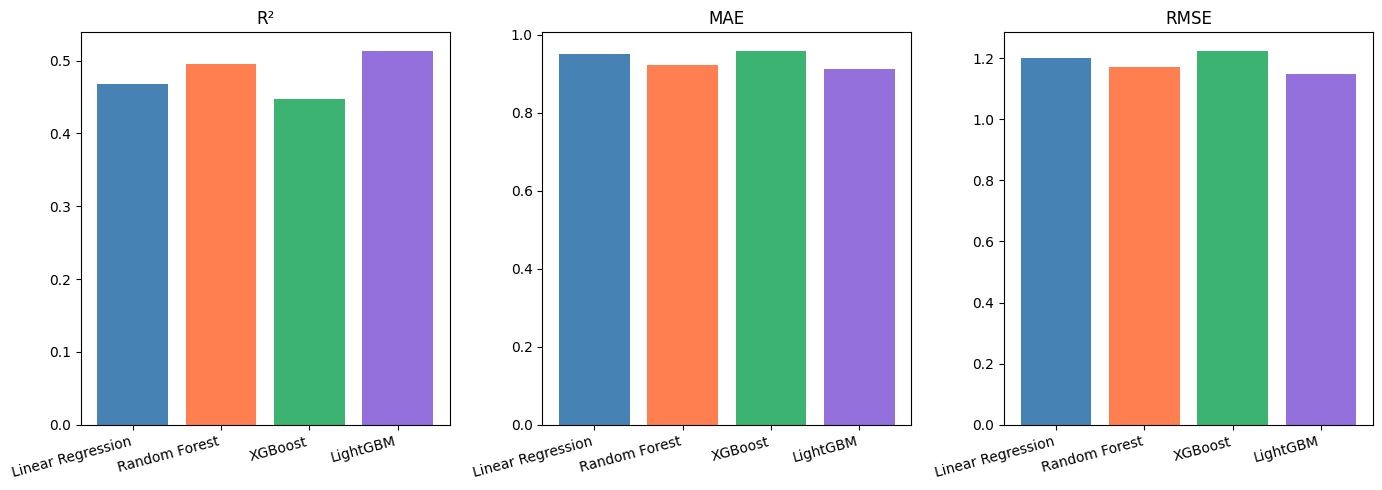

In [51]:
fig, axes = plt.subplots(1, 3, figsize=(14, 5))

metrics = ["R²", "MAE", "RMSE"]
colors = ["steelblue", "coral", "mediumseagreen", "mediumpurple"]

for i, metric in enumerate(metrics):
    axes[i].bar(results_df.index, results_df[metric], color=colors)
    axes[i].set_title(metric)
    axes[i].set_xticks(range(len(results_df.index)))
    axes[i].set_xticklabels(results_df.index, rotation=15, ha="right")

plt.tight_layout()
plt.show()

# <br>
# <br>
## Tuning degli iperparametri
Ottimizziamo gli iperparametri di LightGBM, il modello migliore, usando RandomizedSearchCV. Vengono provate combinazioni casuali di parametri e viene selezionata la migliore tramite cross-validation.

In [52]:
from sklearn.model_selection import RandomizedSearchCV

param_grid = {
    "n_estimators": [100, 200, 300, 500],
    "max_depth": [3, 5, 7, 10, -1],
    "learning_rate": [0.01, 0.05, 0.1, 0.2],
    "num_leaves": [31, 50, 100, 200],
    "subsample": [0.6, 0.8, 1.0],
    "colsample_bytree": [0.6, 0.8, 1.0],
}

random_search = RandomizedSearchCV(
    lgb.LGBMRegressor(random_state=42, verbose=-1),
    param_distributions=param_grid,
    n_iter=50,
    cv=5,
    scoring="r2",
    random_state=42,
    n_jobs=-1
)

random_search.fit(X_train, y_train)

best_model = random_search.best_estimator_
y_pred_tuned = best_model.predict(X_test)

print(f"Migliori parametri: {random_search.best_params_}")
print(f"\nCV R² (miglior combinazione): {random_search.best_score_:.4f}")
print(f"\nTest set:")
print(f"  R²:   {r2_score(y_test, y_pred_tuned):.4f}")
print(f"  MAE:  {mean_absolute_error(y_test, y_pred_tuned):.4f}")
print(f"  RMSE: {np.sqrt(mean_squared_error(y_test, y_pred_tuned)):.4f}")

Migliori parametri: {'subsample': 0.8, 'num_leaves': 100, 'n_estimators': 100, 'max_depth': 5, 'learning_rate': 0.05, 'colsample_bytree': 0.8}

CV R² (miglior combinazione): 0.5298

Test set:
  R²:   0.5182
  MAE:  0.9051
  RMSE: 1.1426


Il tuning degli iperparametri migliora il modello in cross-validation ma sul test set il miglioramento è minimo. Questo suggerisce che il dataset è relativamente piccolo e il modello di default era già vicino al suo limite con questi dati. Useremo comunque il modello tuned come modello finale.

# <br>
### Feature Importance
Visualizziamo le feature più importanti per il modello tuned per capire quali variabili influenzano maggiormente la previsione del revenue.

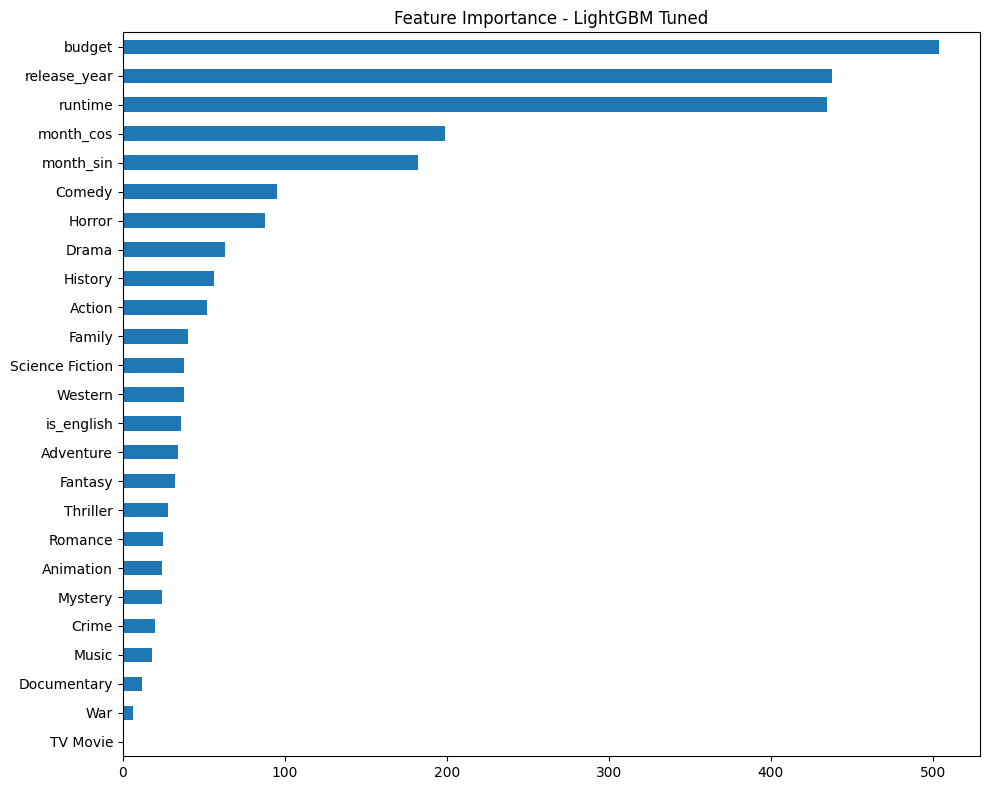

In [53]:
feature_importance = pd.Series(best_model.feature_importances_, index=X.columns)
feature_importance = feature_importance.sort_values(ascending=True)

feature_importance.plot(kind="barh", figsize=(10, 8))
plt.title("Feature Importance - LightGBM Tuned")
plt.tight_layout()
plt.show()

Il budget è di gran lunga la feature più importante, confermando l'analisi di correlazione. Sorprendentemente release_year e runtime sono quasi altrettanto importanti. L'encoding ciclico del mese contribuisce significativamente. Tra i generi, Comedy e Horror sono i più influenti. TV Movie, War e Documentary hanno importanza quasi nulla.

# <br>
## Salvataggio del modello
Salviamo il modello tuned e il MultiLabelBinarizer con joblib per poterli riusare nella webapp senza dover riaddestrare il modello.

In [54]:
import joblib

joblib.dump(best_model, "model.joblib")
joblib.dump(mlb, "mlb.joblib")

print("Modello salvato: model.joblib")
print("MultiLabelBinarizer salvato: mlb.joblib")

Modello salvato: model.joblib
MultiLabelBinarizer salvato: mlb.joblib


In [55]:
print(X.columns.tolist())

['budget', 'runtime', 'release_year', 'month_sin', 'month_cos', 'is_english', 'Action', 'Adventure', 'Animation', 'Comedy', 'Crime', 'Documentary', 'Drama', 'Family', 'Fantasy', 'History', 'Horror', 'Music', 'Mystery', 'Romance', 'Science Fiction', 'TV Movie', 'Thriller', 'War', 'Western']
